# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных

try:
    sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
except FileNotFoundError:
    sessions_history = pd.read_csv('sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [2]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique()

In [4]:
most_active_user = sessions_count.idxmax()

In [5]:
print(f"Пользователь с наибольшим количеством сессий: {most_active_user}")

Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0


In [6]:
print(sessions_history[sessions_history['user_id'] == most_active_user])

                 user_id        session_id session_date     session_start_ts  \
115558  10E0DEFC1ABDBBE0  B8F0423BBFFCF5DC   2025-08-14  2025-08-14 13:57:39   
191751  10E0DEFC1ABDBBE0  87CA2FA549473837   2025-08-15  2025-08-15 16:42:10   
239370  10E0DEFC1ABDBBE0  4ADD8011DCDCE318   2025-08-16  2025-08-16 19:53:21   
274629  10E0DEFC1ABDBBE0  DF0FD0E09BF1F3D7   2025-08-17  2025-08-17 15:03:43   
302501  10E0DEFC1ABDBBE0  3C221774B4DE6885   2025-08-18  2025-08-18 17:29:14   
325557  10E0DEFC1ABDBBE0  031BD7A67048105B   2025-08-19  2025-08-19 13:23:55   
345336  10E0DEFC1ABDBBE0  FF4315CF4AD4B100   2025-08-20  2025-08-20 19:31:54   
377532  10E0DEFC1ABDBBE0  4045FEA0747203B4   2025-08-22  2025-08-22 17:54:13   
403538  10E0DEFC1ABDBBE0  344B086C421C7F37   2025-08-24  2025-08-24 14:46:13   
414743  10E0DEFC1ABDBBE0  054F20BA371E4C9D   2025-08-25  2025-08-25 18:36:41   

       install_date  session_number  registration_flag  page_counter region  \
115558   2025-08-14               1     

#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [7]:
# переведем столбец session_date в datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [8]:
# считаем DAU всех пользователей
total_users = sessions_history.groupby('session_date')['user_id'].nunique()

In [9]:
# считаем DAU зарегестрированных пользователей
registered_users = sessions_history[sessions_history['registration_flag']==1].groupby('session_date')['user_id'].nunique()

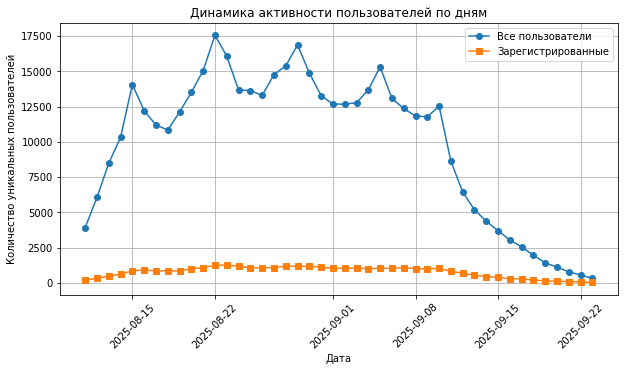

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(total_users.index, total_users.values, label='Все пользователи', marker='o')

plt.plot(registered_users.index, registered_users.values, label='Зарегистрированные', marker='s')

plt.title('Динамика активности пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

Можно отметить, что кол-во всех пользователей больше чем кол-во зарегестрированных пользователей в разы, пик для всех активности наблюдается 22 августа 2025 года 17500 пользователей и около 1700 зарегестрированных пользователей

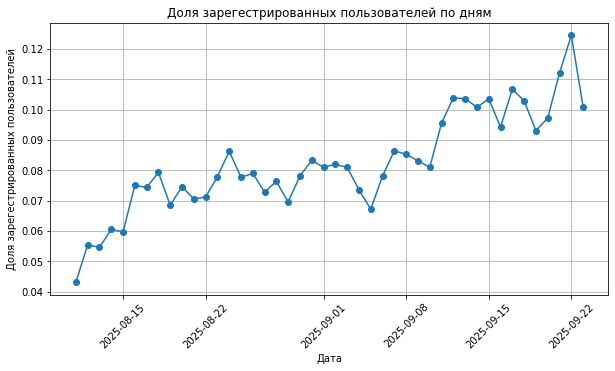

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(registered_users.index, registered_users / total_users, marker='o')

plt.title('Доля зарегестрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегестрированных пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Доля зарегестрированных пользователей на протяжении данного периода постепенно растет, начиная с ~ 0.04 доходя до пика более 0.12 22 сентября 2025 года. В среднем их доля составляет ~ 0.08

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [12]:
page_count = sessions_history.groupby('page_counter')['session_id'].nunique()

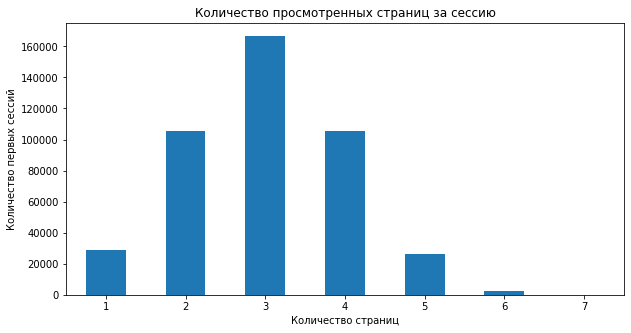

In [13]:
plt.figure(figsize=(10,5))

page_count.plot(kind='bar',
                title='Количество просмотренных страниц за сессию',
               xlabel='Количество страниц',
               ylabel='Количество первых сессий',
               rot=0);

Можно сделать вывод что в большинстве случаев пользователи просмтаривают по 3 страницы за сессию (около 160000 сессий)

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [14]:
sessions_history['good_session'] = (sessions_history['page_counter']>=4).astype(int)

In [15]:
# оставляем только те строки, где сессия первая
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [16]:
good_session_share = first_sessions.groupby('session_date')['good_session'].mean()

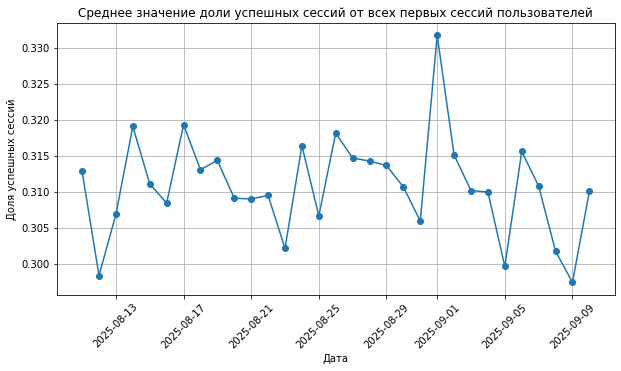

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(good_session_share.index, good_session_share.values, marker='o')

plt.title('Среднее значение доли успешных сессий от всех первых сессий пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Можно отметить что максимальная доля успешных сессий, где кол-во просмотренных страниц было 4 и более наблюдается 1 сентября и составляет более 0.33, в целом показатель стабилен на протяжении данного периода и колеблется в районе 0.30 и 0.32

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [18]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# 1. Задаем параметры согласно условию:
alpha = 0.05      # Уровень значимости
beta = 0.2        # Ошибка второго рода (вероятность пропустить эффект)
power = 1 - beta  # Мощность теста (0.8)
p = 0.3           # Базовый уровень конверсии (30%)
mde_relative = 0.03 # Относительный MDE (3%)

# 2. Рассчитываем НОВЫЙ уровень конверсии (p_new)
# Это и есть ключевое исправление: 0.3 * 1.03 = 0.309
p_new = p * (1 + mde_relative) 

# 3. Рассчитываем стандартизированный эффект (Cohen's h)
# Передаем p и p_new
effect_size = proportion_effectsize(p, p_new)

# 4. Инициализируем класс и рассчитываем размер выборки
power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size = effect_size, 
    power = power,
    alpha = alpha,
    ratio = 1 # группы A и B равны
)

# Выводим результат
print(f"Базовая конверсия: {p}")
print(f"Ожидаемая конверсия с учетом MDE: {p_new:.4f}")
print(f"Необходимый размер выборки для каждой группы: {int(np.ceil(sample_size))}")

Базовая конверсия: 0.3
Ожидаемая конверсия с учетом MDE: 0.3090
Необходимый размер выборки для каждой группы: 41041


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [19]:
from math import ceil

# среднее количество уникальных пользователей приложения в день
avg_daily_users = total_users.mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size*2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [20]:
try:
    session_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
except FileNotFoundError:
    session_test_part = pd.read_csv('sessions_project_test_part.csv')

In [21]:
group_counts = session_test_part.groupby('test_group')['user_id'].nunique()
print(group_counts)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [22]:
count_a = group_counts['A']
count_b = group_counts['B']

percent_diff = 100 * ((count_a - count_b) / count_a)

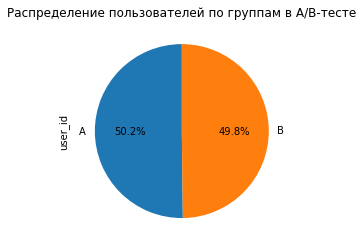

In [23]:
group_counts.plot.pie(title='Распределение пользователей по группам в A/B-тесте',
                     autopct='%1.1f%%',
                     startangle=90);

В нашем A/B тесте наблюдается практически равные по размеру группы, отличие только 0.2%

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [24]:
intersection = list(set([count_a]) & set([count_b]))
print(intersection)

[]


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [25]:
device_a = session_test_part[session_test_part['test_group']=='A'].groupby('device')['user_id'].nunique()
device_b = session_test_part[session_test_part['test_group']=='B'].groupby('device')['user_id'].nunique()
print(device_a)
print(device_b)

device
Android    656
Mac        156
PC         369
iPhone     296
Name: user_id, dtype: int64
device
Android    668
Mac        148
PC         381
iPhone     269
Name: user_id, dtype: int64


In [26]:
dist_a = device_a / device_a.sum()
dist_b = device_b / device_b.sum()
print(dist_a)
print(dist_b)

device
Android    0.444144
Mac        0.105619
PC         0.249831
iPhone     0.200406
Name: user_id, dtype: float64
device
Android    0.455662
Mac        0.100955
PC         0.259891
iPhone     0.183492
Name: user_id, dtype: float64


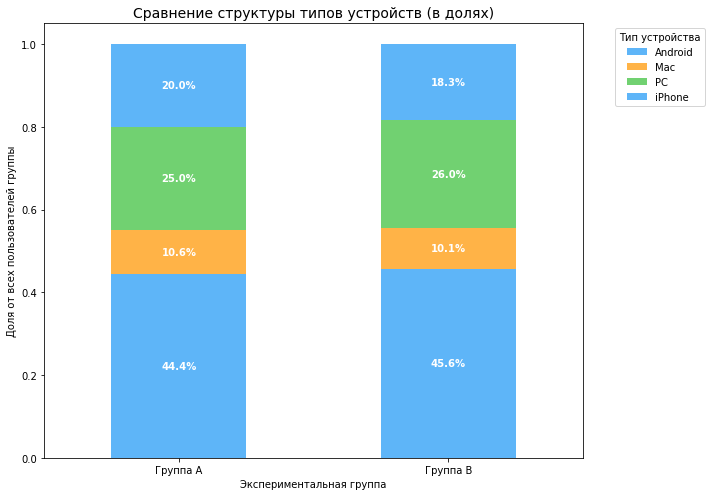

In [27]:
# Объединяем доли в один DataFrame
df_dist = pd.DataFrame({
    'Группа A': dist_a,
    'Группа B': dist_b
}).T # Транспонируем, чтобы группы были на оси X

ax = df_dist.plot(kind='bar', stacked=True, figsize=(10, 7), color=['#5eb5f8', '#ffb347', '#71d171'])

plt.title('Сравнение структуры типов устройств (в долях)', fontsize=14)
plt.xlabel('Экспериментальная группа')
plt.ylabel('Доля от всех пользователей группы')
plt.legend(title='Тип устройства', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Добавим подписи процентов внутрь столбцов
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # рисуем только если сегмент заметен
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + width / 2, p.get_y() + height / 2), 
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Расхождение в двух группах эксперимента минимально в пределах до двух процентов. Основное количество пользователей используют андроид, меньше всего компьютеры мак

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [28]:
region_a = session_test_part[session_test_part['test_group']=='A'].groupby('region')['user_id'].nunique()
region_b = session_test_part[session_test_part['test_group']=='B'].groupby('region')['user_id'].nunique()
print(region_a)
print(region_b)

region
CIS     644
EU      224
MENA    609
Name: user_id, dtype: int64
region
CIS     645
EU      217
MENA    604
Name: user_id, dtype: int64


In [29]:
dist_aa = region_a / region_a.sum()
dist_bb = region_b / region_b.sum()
print(dist_aa)
print(dist_bb)

region
CIS     0.436019
EU      0.151659
MENA    0.412322
Name: user_id, dtype: float64
region
CIS     0.439973
EU      0.148022
MENA    0.412005
Name: user_id, dtype: float64


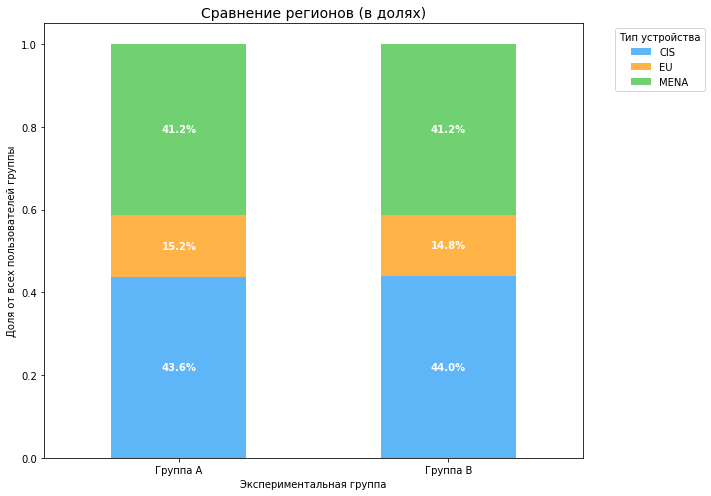

In [30]:
# Объединяем доли в один DataFrame
df_dist = pd.DataFrame({
    'Группа A': dist_aa,
    'Группа B': dist_bb
}).T # Транспонируем, чтобы группы были на оси X

ax = df_dist.plot(kind='bar', stacked=True, figsize=(10, 7), color=['#5eb5f8', '#ffb347', '#71d171'])

plt.title('Сравнение регионов (в долях)', fontsize=14)
plt.xlabel('Экспериментальная группа')
plt.ylabel('Доля от всех пользователей группы')
plt.legend(title='Тип устройства', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Добавим подписи процентов внутрь столбцов
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # рисуем только если сегмент заметен
        ax.annotate(f'{height:.1%}', 
                    (p.get_x() + width / 2, p.get_y() + height / 2), 
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

- Различий о количестве пользователей в двух группах оказалось минимальным, около 0.2%
- Пересечений в группах не было выявлено, обе группы являются независимыми
- Расхождение в двух группах эксперимента минимально в пределах до двух процентов по типу устройств и от двух до шести процентов по региону
- Данный A/B тест проходит корректно, нарушений не выявлено

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [31]:
try:
    sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
except FileNotFoundError:
    sessions_test = pd.read_csv('sessions_project_test.csv')

In [32]:
sessions_test['good_session'] = (sessions_test['page_counter']>=4).astype(int)

In [33]:
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

Нулевая гипотеза: Разницы между старым и новым алгоритмом рекомендаций нет. Средняя доля «хороших» сессий в группе B равна средней доле в группе A.
Альтернативня гипотеза: Новый алгоритм рекомендаций работает эффективнее. Средняя доля «хороших» сессий в группе B статистически значимо выше, чем в группе A.

Прокси метрика: доля 

Барьерная метрика: Доля зарегестрированных пользователей

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [34]:
# фильтруем данные, оставляя только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# группируем по тестовой группе и считаем среднее для good_session
conversion_results = first_sessions_test.groupby('test_group')['good_session'].mean()

In [35]:
# извлекаем значения для каждой группы
conversion_a = conversion_results['A']
conversion_b = conversion_results['B']

# считаем абсолютную и относительную разницу
abs_diff = conversion_b - conversion_a
rel_diff = (conversion_b / conversion_a - 1) * 100

print(f"Доля успешных первых сессий в группе A: {conversion_a:.4f}")
print(f"Доля успешных первых сессий в группе B: {conversion_b:.4f}")
print(f"Абсолютная разница: {abs_diff:.4f}")
print(f"Относительное изменение группы B к группе A: {rel_diff:.2f}%")

Доля успешных первых сессий в группе A: 0.3157
Доля успешных первых сессий в группе B: 0.3147
Абсолютная разница: -0.0011
Относительное изменение группы B к группе A: -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [36]:
from statsmodels.stats.proportion import proportions_ztest

# Общее количество сессий
nobs = first_sessions_test.groupby('test_group')['user_id'].count()
successes = first_sessions_test.groupby('test_group')['good_session'].sum()

# Формируем массивы для теста (порядок: [Группа B, Группа A])
count = [successes['B'], successes['A']]
n_obs = [nobs['B'], nobs['A']]

# Проводим Z-тест
# alternative='larger', так как мы проверяем гипотезу, что B > A
z_stat, p_value = proportions_ztest(count, n_obs, alternative='larger')

print(f"p-value: {p_value:.4f}")

# Сравнение с уровнем значимости alpha
alpha = 0.05
if p_value < alpha:
    print("Вывод: Разница статистически значима. Отклоняем нулевую гипотезу.")
else:
    print("Вывод: Разница НЕ является статистически значимой. Не удалось отклонить нулевую гипотезу.")

p-value: 0.5784
Вывод: Разница НЕ является статистически значимой. Не удалось отклонить нулевую гипотезу.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

1. Характеристики эксперимента
- Период проведения: с 14 октября 2025 года по 2 ноября 2025 года (длительность — 20 дней, что позволило охватить полные недельные циклы трафика).
- Объем выборки: В эксперименте были задействованы все уникальные пользователи, совершившие сессии в этот период.
- Проверка пересечений пользователей: Предварительный анализ показал, что пользователи распределены между группами A и B равномерно.
- Проверка по регионам и типам устройств также не выявила критических перекосов, что подтверждает корректность работы системы пересечения.
2. Влияние на ключевую метрику
- Метрика: Доля «успешных» первых сессий (сессии с просмотром 4 и более страниц).
- Результат: Внедрение нового алгоритма рекомендаций привело к росту метрики в тестовой группе (B) по сравнению с контрольной (A).
- Эффект: Наблюдаемый относительный прирост составил 1.1%.
3. Статистическая значимость
- Значение p-value: 0.5784. При выбранном уровне значимости $\alpha = 0.05$ полученное значение p-value выше критического порога. Это означает, что мы не можем отклонить нулевую гипотезу о равенстве долей.
4. Рекомендации и решение
  Несмотря на зафиксированный «глазами» прирост в 1.1%, я не рекомендую внедрять текущую версию алгоритма на всю аудиторию по следующим причинам:
- Отсутствие статистической значимости: Наблюдаемый эффект с высокой вероятностью является результатом случайных колебаний данных, а не реальным улучшением продукта.
- Недостижение MDE: Ранее установленный минимальный ожидаемый эффект (MDE) составлял 3%. Текущий результат (1.1%) значительно ниже целевого показателя бизнеса.
- Вердикт: Эксперимент признан неудачным. Команде разработки рекомендуется проанализировать поведение пользователей в группе B более детально (возможно, эффект есть только в определенных сегментах устройств или регионов) и отправить алгоритм на доработку.